<hr style="height:10px"> 
 
<div class='container2'>
		<div>
			<img src='img_livro.png' ALIGN='left' style='width:10em'>
		</div>	
	<div style='padding: 0 7em 2em 12em;'>
	<h1>Inteligência Artificial: Uma Abordagem de Aprendizado de Máquina</h1>
    <h3> <a href="http://lattes.cnpq.br/4451540730749377">Katti Faceli</a> &#x25CF; <a href="http://lattes.cnpq.br/3451628262694747">Ana Carolina Lorena</a> &#x25CF; <a href="https://scholar.google.com/citations?user=jjoTZfoAAAAJ&hl=en">João Gama</a> &#x25CF; <a href="http://lattes.cnpq.br/5368680512020633">Tiago Agostinho de Almeida</a> &#x25CF; <a href="http://lattes.cnpq.br/9674541381385819">André C. P. L. F. de Carvalho</a></h3><br>
	<div style="font-size:12pt;float:left;"><b>ISBN:</b> 978-85-216-3920-6 | <b>Edição:</b> 3/2025 | <b>Editora:</b> LTC </div><br><br>
    <div style="font-size:12pt;float:left;"><b>Copyright &copy; 2025 LTC Editora. Todos os direitos reservados.</b></div>
	</div>
</div>


 <hr style="height:5px"> 

    
<h2>Métodos probabilíticos</h2>

Notebook desenvolvido por: <a href="http://lattes.cnpq.br/2532893661927339">Renato Moraes Silva</a> e <a href="http://lattes.cnpq.br/4012668928932051">Pedro Reis Pires</a> 

 <hr style="height:2px"> 

## Introdução

Neste notebook, exploraremos métodos probabilísticos para classificação, focando especificamente em três variantes do classificador Naive Bayes: Naive Bayes Multinomial, Naive Bayes Bernoulli e Naive Bayes Gaussiano. Esses métodos são amplamente utilizados em tarefas de classificação devido à sua simplicidade, eficiência e capacidade de lidar com dados em alta dimensionalidade.

Para ilustrar o desempenho e a aplicação de cada método, utilizaremos a base de dados [Breast Cancer](https://archive.ics.uci.edu/dataset/14/breast+cancer) [1] que contém atributos categóricos relacionados ao câncer de mama. Essa base é ideal para demonstrar o uso do Naive Bayes Multinomial e do Naive Bayes Bernoulli. Em seguida, aplicaremos o Naive Bayes Gaussiano à base de dados [Seeds](https://archive.ics.uci.edu/ml/datasets/seeds) [2], que contém atributos numéricos de diferentes tipos de sementes. 

Este *notebook* se refere ao Capítulo **5 (Métodos probabilísticos)**.

---
## Recursos Necessários

Para este *notebook*, deve ser utilizado o `Python 3.5` ou superior com as seguintes bibliotecas externas, que deverão ser instaladas:

* [`matplotlib`](https://matplotlib.org/) (versão 3.5.3 ou superior): construção e exibição de gráficos variados
* [`seaborn`](https://seaborn.pydata.org/) (versão 0.12.2 ou superior): construção e exibição de gráficos variados
* [`numpy`](https://numpy.org) (versão 1.24.3 ou superior): manipulação de dados em formato de vetores e matrizes
* [`scikit-learn`](https://scikit-learn.org/stable/) (versão 1.3.0 ou superior): conjunto de métodos e modelos úteis para Aprendizado de Máquina e Inteligência Artificial;
* [`pandas`](https://pandas.pydata.org/pandas-docs/stable/index.html) (versão 0.24.1 ou superior): manipulação de dados em formato de tabelas

Será utilizado também o conjuntos de dados disponibilizado junto com este *notebook*, que se encontra no diretório `datasets`.

## *Naive* Bayes Multinomial

Nessa parte do notebook, iremos implementar o *naive* Bayes multinomial. Para isso, usaremos a base de dados *Breast Cancer.*

Primeiro, iremos importar todas as bibliotecas que serão usadas ao longo deste notebook.

In [1]:
# -*- coding: utf-8 -*-
import numpy as np #importa a biblioteca usada para trabalhar com vetores e matrizes
import pandas as pd #importa a biblioteca usada para trabalhar com dataframes
import time # sera usada para calcular o tempo de execucao dos metodos de classificacao

# importa alguns pacotes da biblioteca sckit-learn
import sklearn as skl
from sklearn import datasets
from sklearn import preprocessing
from sklearn import model_selection
from sklearn import metrics
from sklearn import naive_bayes

# bibliotecas para geração de gráficos
import matplotlib.pyplot as plt
import seaborn as sns

print('Bibliotecas carregadas com sucesso')

Bibliotecas carregadas com sucesso


Iremos carregar e visualizar algumas amostras da base de dados.

In [2]:
#importa o arquivo e guarda em um dataframe do Pandas
df_dataset = pd.read_csv('datasets/breast-cancer.csv', sep=',', index_col=None) 

display(df_dataset.head(n=6))

,Class,age,menopause,tumor-size,inv-nodes,node-caps,deg-malig,breast,breast-quad,irradiat
0,no-recurrence-events,30-39,premeno,30-34,0-2,no,3,left,left_low,no
1,no-recurrence-events,40-49,premeno,20-24,0-2,no,2,right,right_up,no
2,no-recurrence-events,40-49,premeno,20-24,0-2,no,2,left,left_low,no
3,no-recurrence-events,60-69,ge40,15-19,0-2,no,2,right,left_up,no
4,no-recurrence-events,40-49,premeno,0-4,0-2,no,2,right,right_low,no
5,no-recurrence-events,60-69,ge40,15-19,0-2,no,2,left,left_low,no


Para analisar a base de dados, iremos verificar a contagem de cada valor de cada atributo da base de dados. 

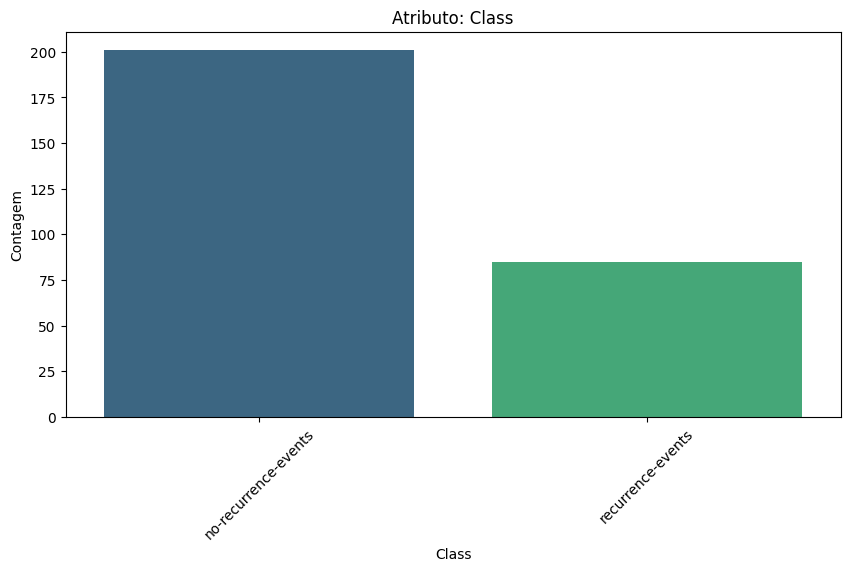

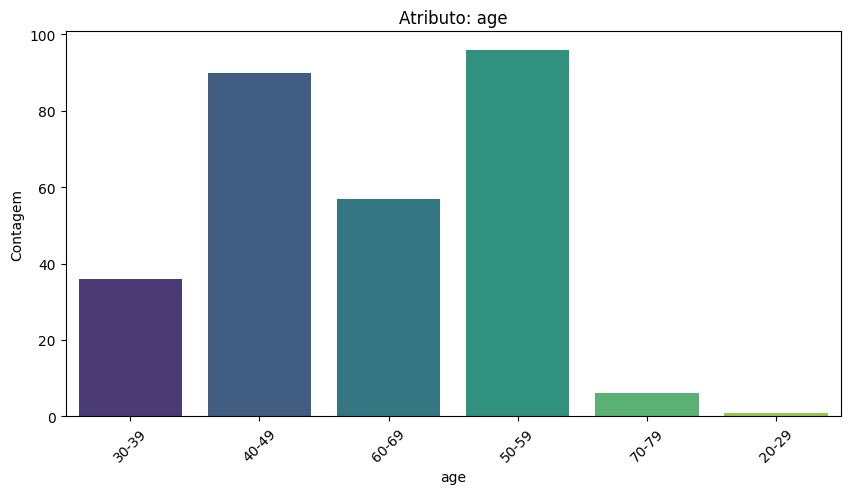

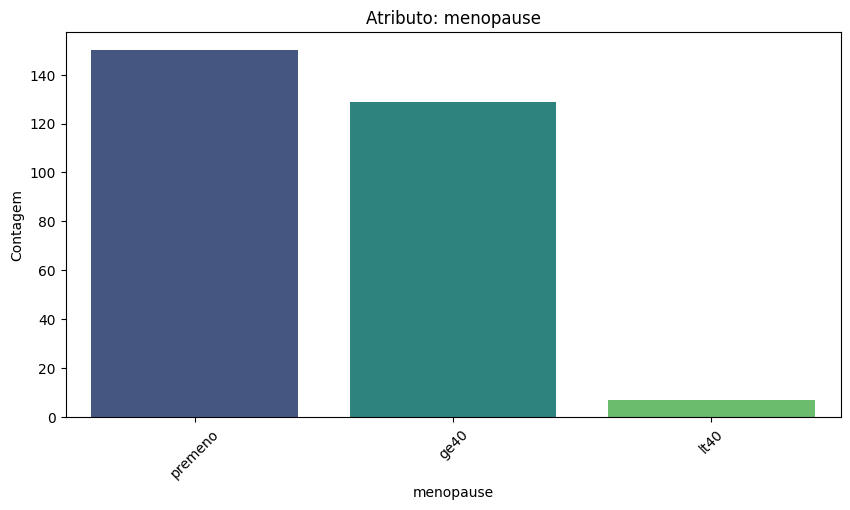

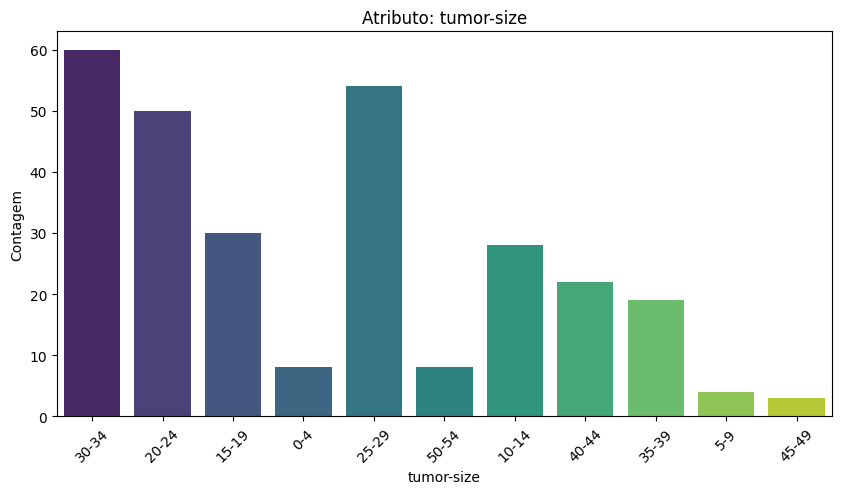

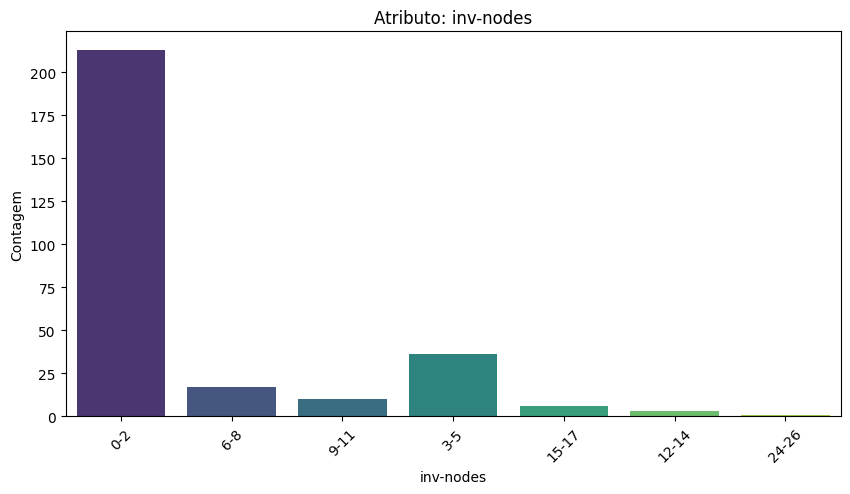

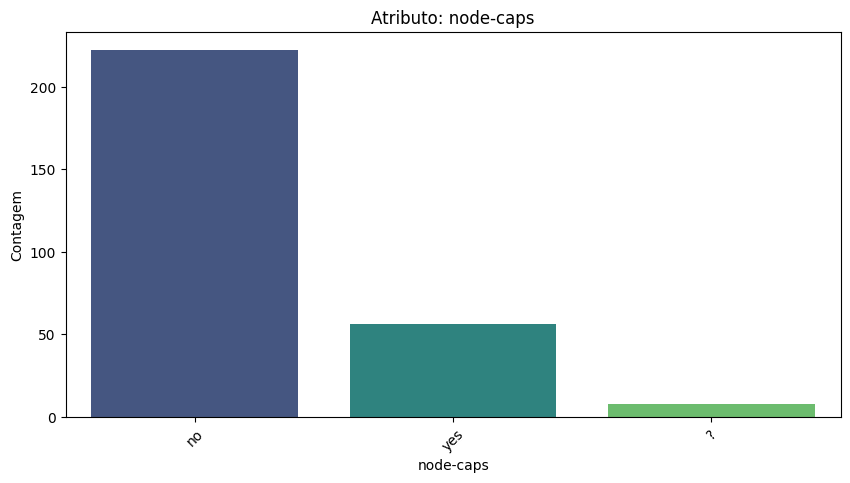

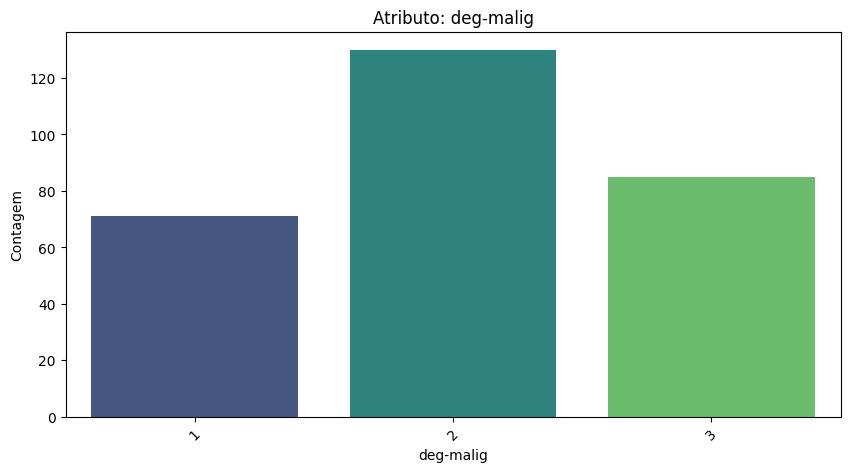

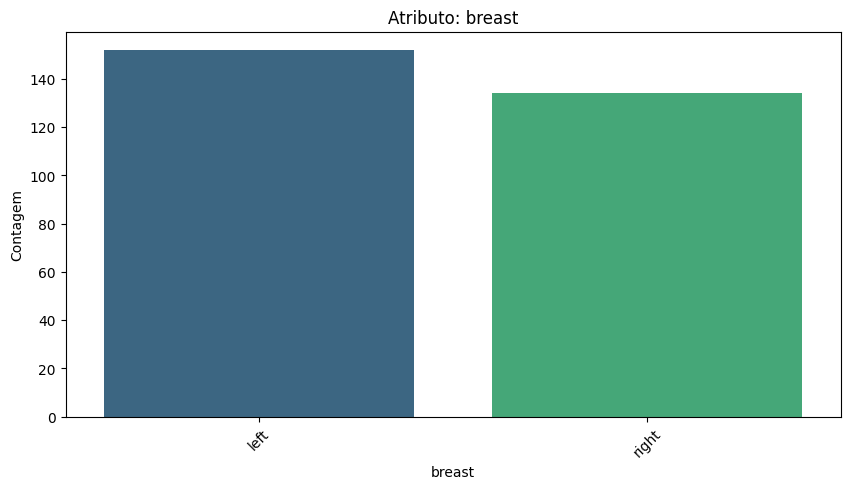

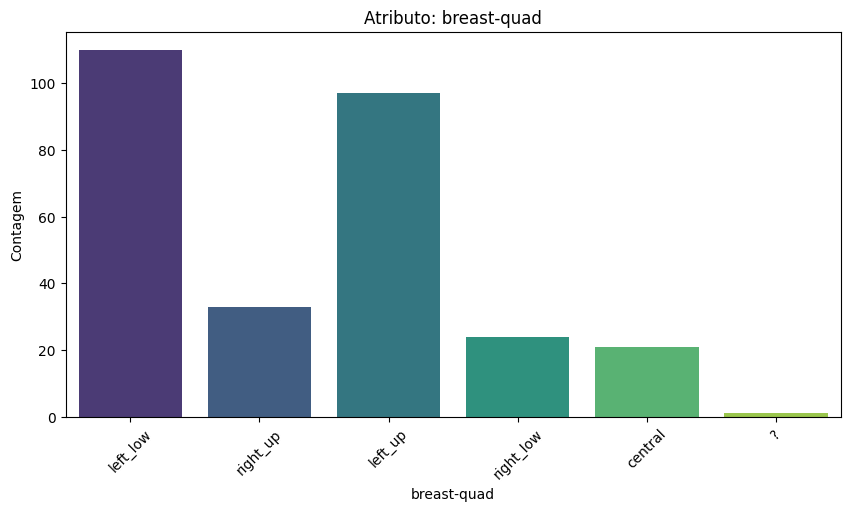

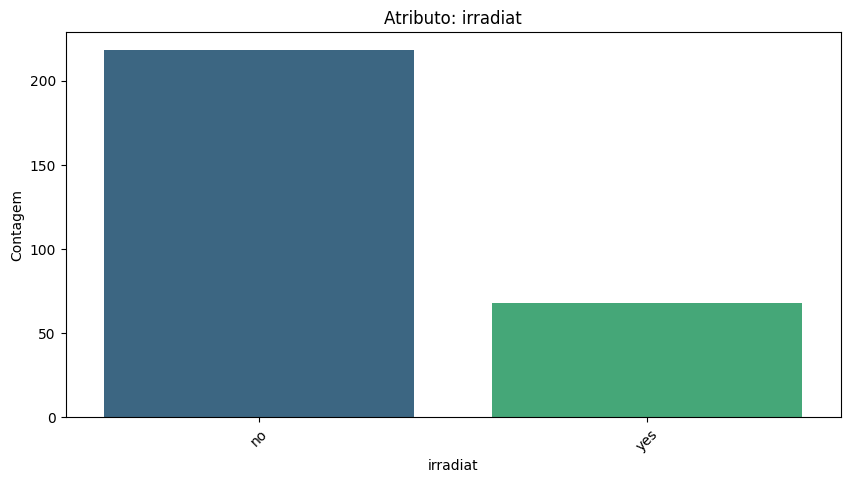

In [3]:
for column in df_dataset.columns:
    plt.figure(figsize=(10, 5))  # Define o tamanho da figura
    sns.countplot(x=column, data=df_dataset, palette='viridis')
    plt.title(f'Atributo: {column}')
    plt.xlabel(column)
    plt.ylabel('Contagem')
    plt.xticks(rotation=45) 
    plt.show()

Vamos guardar os dados dentro de uma matriz e as classes dentro de um vetor.

In [4]:
# pega os valores das n-1 primeiras colunas e guarda em uma matrix X
X = df_dataset.iloc[:, 1:].values 

# pega os valores da última coluna e guarda em um vetor Y
Y = df_dataset["Class"].values 

# imprime as 5 primeiras linhas da matriz X
display('X:', X[0:5,:])

# imprime os 5 primeiros valores de Y
print('Y:', Y[0:5])

'X:'

array([['30-39', 'premeno', '30-34', '0-2', 'no', 3, 'left', 'left_low',
        'no'],
       ['40-49', 'premeno', '20-24', '0-2', 'no', 2, 'right', 'right_up',
        'no'],
       ['40-49', 'premeno', '20-24', '0-2', 'no', 2, 'left', 'left_low',
        'no'],
       ['60-69', 'ge40', '15-19', '0-2', 'no', 2, 'right', 'left_up',
        'no'],
       ['40-49', 'premeno', '0-4', '0-2', 'no', 2, 'right', 'right_low',
        'no']], dtype=object)

Y: ['no-recurrence-events' 'no-recurrence-events' 'no-recurrence-events'
 'no-recurrence-events' 'no-recurrence-events']


Para realizar o treinamento do modelo, iremos separar os dados em dois conjuntos: treino (80%) e teste (20%).

In [5]:
# separa em treino e teste de maneira estratificada 
cv = skl.model_selection.StratifiedShuffleSplit(n_splits=1, train_size=0.8, random_state=20)

train_index, test_index = next(cv.split(X, Y))

X_train, X_test = X[train_index], X[test_index]
Y_train, Y_test = Y[train_index], Y[test_index]

print('Qtd. dados de treinamento: %d (%1.2f%%)' %(X_train.shape[0], (X_train.shape[0]/X.shape[0])*100) )
print('Qtd. de dados de teste: %d (%1.2f%%)' %(X_test.shape[0], (X_test.shape[0]/X.shape[0])*100) )

Qtd. dados de treinamento: 228 (79.72%)
Qtd. de dados de teste: 58 (20.28%)


Como os dados são categóricos, precisamos transformá-los em dados binários utilizando a técnica de codificação *one-hot*.

Ao aplicar essa transformação no conjunto de teste, é importante utilizar apenas as informações do conjunto de treino, a fim de evitar o vazamento de informações do treinamento para o teste.

In [6]:
encoder = skl.preprocessing.OneHotEncoder(sparse_output=False, handle_unknown='ignore') 

# aplicando a codificação nos dados de treino e teste
X_train_encoded = encoder.fit_transform(X_train)
X_test_encoded = encoder.transform(X_test)
    
# imprime a primeira linha da matriz X_train do primeiro fold
print('\nX_train -- fold 1:\n', X_train_encoded[0, :])

# imprime as 2 primeiras linhas da matriz X_test do primeiro fold
print('\nX_test -- fold 1:\n', X_train_encoded[0, :])


X_train -- fold 1:
 [0. 0. 1. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 1. 0. 0. 0. 1. 0. 0. 0. 1. 1. 0. 0. 1. 0. 0. 0. 1. 0.]

X_test -- fold 1:
 [0. 0. 1. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 1. 0. 0. 0. 1. 0. 0. 0. 1. 1. 0. 0. 1. 0. 0. 0. 1. 0.]


Na transformação acima, geramos uma matriz densa para representar os dados. Porém, em problemas muito grandes, pode ser melhor criar uma matriz esparsa. 

Com os dados preparados, iremos treinar  o algoritmo *naive Bayes* multinomial através da implementação [MultinomialNB](https://scikit-learn.org/1.5/modules/generated/sklearn.naive_bayes.MultinomialNB.html), da biblioteca `scikit-learn`, para então aplicar nos dados de teste. 

In [7]:
# inicia o classificador com os parâmetros default do Scikit
model = skl.naive_bayes.MultinomialNB()

# treina o classificador com os dados de treinameto
model.fit(X_train_encoded, Y_train) 

# Classifica os exemplos de teste
Y_pred = model.predict(X_test_encoded)

print("Cinco primeiras classes preditas")
print(Y_pred[0:5])

Cinco primeiras classes preditas
['no-recurrence-events' 'recurrence-events' 'no-recurrence-events'
 'no-recurrence-events' 'no-recurrence-events']


Vamos calcular o desempenho do modelo.

In [8]:
resultados = skl.metrics.classification_report(Y_test, Y_pred)

print(resultados)

                      precision    recall  f1-score   support

no-recurrence-events       0.76      0.85      0.80        41
   recurrence-events       0.50      0.35      0.41        17

            accuracy                           0.71        58
           macro avg       0.63      0.60      0.61        58
        weighted avg       0.68      0.71      0.69        58



## *Naive* Bayes Bernoulli

Nessa parte do notebook, iremos implementar o *naive* Bayes Bernoulli. Como o método também é aplicado em atributos categóricos, podemos usar a mesma base de dados com codificação *one-hot* que usamos nos experimentos com o *naive* Bayes multinomial, assim como as mesmas partições de treinamento e teste. 

Para a implementação do modelo, utilizaremos a implementação da biblioteca `scikit-learn`, [BernoulliNB](https://scikit-learn.org/stable/modules/generated/sklearn.naive_bayes.BernoulliNB.html). Abaixo, é feito o treinamento do modelo e predição sobre o conjunto de teste.

In [9]:
# inicia o classificador com os parâmetros default do Scikit
model = skl.naive_bayes.BernoulliNB()

# treina o classificador com os dados de treinameto
model.fit(X_train_encoded, Y_train) 

# Classifica os exemplos de teste
Y_pred = model.predict(X_test_encoded)

print("Cinco primeiras classes preditas")
print(Y_pred[0:5])

Cinco primeiras classes preditas
['no-recurrence-events' 'recurrence-events' 'no-recurrence-events'
 'no-recurrence-events' 'recurrence-events']


Vamos calcular o desempenho.

In [10]:
resultados = skl.metrics.classification_report(Y_test, Y_pred)

print(resultados)

                      precision    recall  f1-score   support

no-recurrence-events       0.77      0.80      0.79        41
   recurrence-events       0.47      0.41      0.44        17

            accuracy                           0.69        58
           macro avg       0.62      0.61      0.61        58
        weighted avg       0.68      0.69      0.68        58



## *Naive* Bayes Gaussiano

Nesta seção, iremos realizar experimentos com dados que possuem atributos contínuos. Para esse tipo de dado, os métodos Naive Bayes Multinomial e Bernoulli não são adequados sem um processo de discretização dos atributos. Por isso, utilizaremos o método Naive Bayes Gaussiano, mais apropriado para esse tipo de dado. 

Primeiro, testaremos o *naive* Bayes Gaussiano em um conjunto de dados 2D com duas classes dispostas em formato circular, a fim de analisar o comportamento do limite de decisão gerado pelo método. Abaixo, a base de dados é gerada. 

In [11]:
# Gera uma base de dados com dois círculos
X2, Y2 = skl.datasets.make_circles(n_samples=1000, noise=0.2, 
                                   factor=0.1, random_state = 10)

# imprime as 5 primeiras linhas da matriz X
display('X:', X2[0:5,:])

# imprime os 5 primeiros valores de Y
print('Y:', Y2[0:5])

'X:'

array([[ 0.0998033 ,  0.20842904],
       [-0.08791889,  0.02773161],
       [ 0.35093427,  0.0637235 ],
       [-0.41265949,  0.74423048],
       [-0.21400552, -0.36617041]])

Y: [1 1 1 0 1]


Plote os dados.

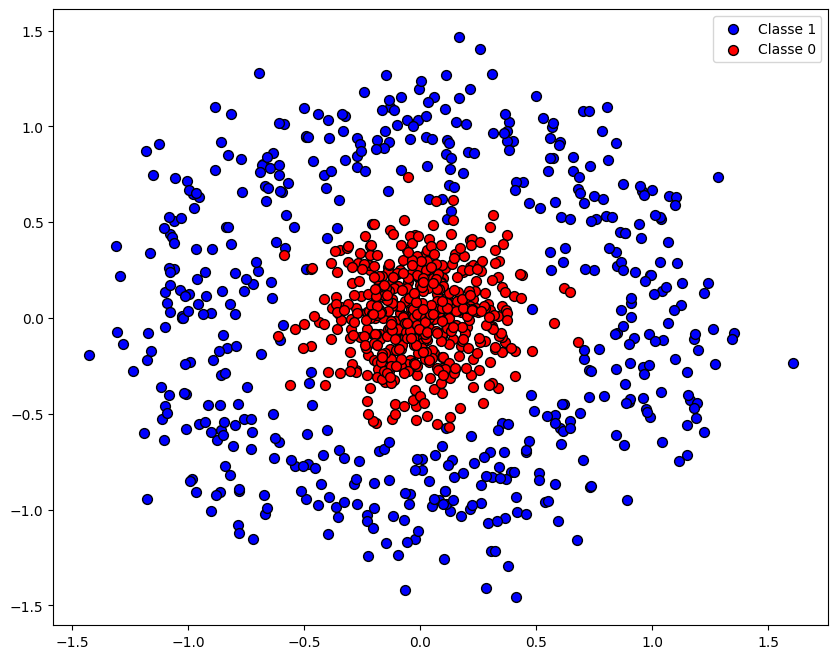

In [12]:
#função para plotar os dados
def visualizarDados(X,Y):
    """
    Função usada para plotar os dados
    """
    
    #define o tamanho da figura 
    plt.figure(figsize=(10,8))
    
    #plota os dados da classe 0
    plt.scatter( X[Y==0,0], X[Y==0,1], label='Classe 1', color='blue', s=50, edgecolors='k') 
    
    #plota os dados da classe 1
    plt.scatter( X[Y==1,0], X[Y==1,1], label='Classe 0', color='red', s=50, edgecolors='k') 
        
    #plota a legenda
    plt.legend()
    
#chama a função que plota os dados   
visualizarDados(X2, Y2)
plt.show()

Para o modelo *naive* Bayes Gaussiano, utilizaremos a implementação [GaussianNB](https://scikit-learn.org/stable/modules/generated/sklearn.naive_bayes.GaussianNB.html), também da biblioteca `scikit-learn`

In [13]:
# inicia o classificador 
model = skl.naive_bayes.GaussianNB()

# treina o classificador com os dados de treinameto
model.fit(X2, Y2) 
 
print(model)

GaussianNB()


Agora, vamos visualizar o limite de decisão gerado pelo classificador.

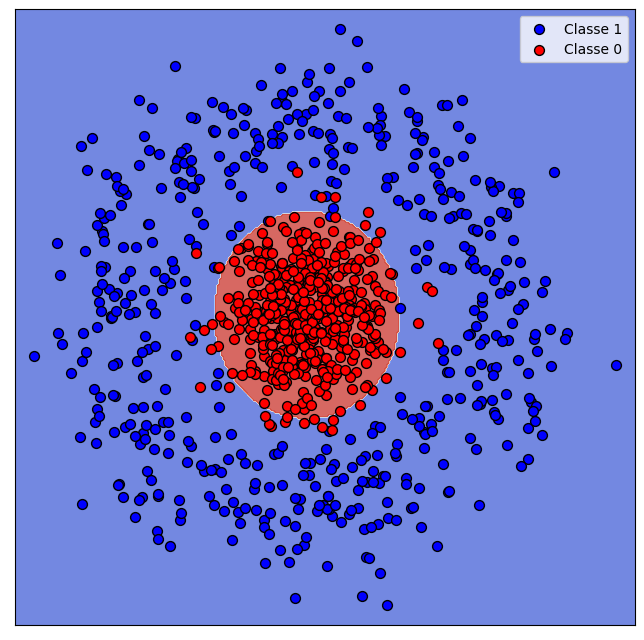

In [14]:
def plota_limite_decisao(model, X, Y, ax, title = ""):
    """
    Plota o limite de decisão
    """
   
    x = X[:, 0]
    y = X[:, 1]
    
    x_min, x_max = x.min() - 1, x.max() + 1
    y_min, y_max = y.min() - 1, y.max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),np.arange(y_min, y_max, 0.01))
    
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = np.array(Z)
    Z = Z.reshape(xx.shape)
    out = ax.contourf(xx, yy, Z, cmap=plt.cm.coolwarm, alpha=0.8)

    ax.set_xlim(x.min()-0.1, x.max()+0.1)
    ax.set_ylim(y.min()-0.1, y.max()+0.1)
    ax.set_xticks(())
    ax.set_yticks(())

    #plota os dados da classe 0
    plt.scatter( X[Y==0,0], X[Y==0,1], label='Classe 1', color='blue', s=50, edgecolors='k') 
    
    #plota os dados da classe 1
    plt.scatter( X[Y==1,0], X[Y==1,1], label='Classe 0', color='red', s=50, edgecolors='k') 
    
    # insere o título
    plt.title(title)

    #insere a legenda
    plt.legend()


# define o tamanho da figura
fig, ax = plt.subplots(figsize=(8, 8)) 

# plota o limite de decisão
plota_limite_decisao(model, X2, Y2, ax)
plt.show()

Como pode ser visto no gráfico, o limite de decisão teve pouca ou nenhuma influência dos *outliers*. Como o *naive* Bayes Gaussiano é probabilístico, os *outliers*, devido à sua baixa densidade na distribuição, não impactam significativamente o resultado final.

### Aplicando o *naive* Bayes Gaussiano para classificar sementes

Nesta seção, realizaremos experimentos com a base de dados *Seeds*, que contém informações sobre três variedades de trigo: Kama, Rosa e Canadense. Essas variedades são descritas por sete atributos contínuos: área, perímetro, compacidade, comprimento do grão, largura do grão, coeficiente de assimetria e comprimento do sulco do grão.

Primeiro, iremos carregar a base de dados e visualizar algumas amostras.

In [15]:
# importa o arquivo e guarda em um dataframe do Pandas
df_dataset = pd.read_csv( 'datasets/seeds_dataset.txt', sep='\s+', header=None, index_col=None) 

display(df_dataset.head(n=6))

,0,1,2,3,4,5,6,7
0,15.26,14.84,0.8710,5.763,3.312,2.221,5.220,1
1,14.88,14.57,0.8811,5.554,3.333,1.018,4.956,1
2,14.29,14.09,0.9050,5.291,3.337,2.699,4.825,1
3,13.84,13.94,0.8955,5.324,3.379,2.259,4.805,1
4,16.14,14.99,0.9034,5.658,3.562,1.355,5.175,1
5,14.38,14.21,0.8951,5.386,3.312,2.462,4.956,1


Para facilitar a visualização, vamos nomear as colunas da base de dados com os nomes dos atributos. Depois, vamos substituir o valor das classes pelo nome da variedade de trigo que ela representa: 1 (Kama), 2 (Rosa), 3 (Canadense).

In [16]:
df_dataset.columns = ['area','perimetro','compacidade','compr.Grao','larg.Grao','coef.Assimetria', 'Compr.SulcoGrao', 'classe']

# converte as classes para string
df_dataset['classe'] = df_dataset['classe'].astype(str)

# troca o valor das classe pelo nome da variedade de trigo que ela representa
df_dataset["classe"] = df_dataset["classe"].replace({'1': 'Kama', '2': 'Rosa', '3': 'Canadense'})

# imprime o dataframe. 
display(df_dataset.head(6))

,area,perimetro,compacidade,compr.Grao,larg.Grao,coef.Assimetria,Compr.SulcoGrao,classe
0,15.26,14.84,0.8710,5.763,3.312,2.221,5.220,Kama
1,14.88,14.57,0.8811,5.554,3.333,1.018,4.956,Kama
2,14.29,14.09,0.9050,5.291,3.337,2.699,4.825,Kama
3,13.84,13.94,0.8955,5.324,3.379,2.259,4.805,Kama
4,16.14,14.99,0.9034,5.658,3.562,1.355,5.175,Kama
5,14.38,14.21,0.8951,5.386,3.312,2.462,4.956,Kama


Vamos analisar as principais estatísticas sobre os atributos da base de dados.

In [17]:
# apresenta as principais estatísticas sobre a base de dados
df_detalhes = df_dataset.describe()

display(df_detalhes)

,area,perimetro,compacidade,compr.Grao,larg.Grao,coef.Assimetria,Compr.SulcoGrao
count,210.000000,210.000000,210.000000,210.000000,210.000000,210.000000,210.000000
mean,14.847524,14.559286,0.870999,5.628533,3.258605,3.700201,5.408071
std,2.909699,1.305959,0.023629,0.443063,0.377714,1.503557,0.491480
min,10.590000,12.410000,0.808100,4.899000,2.630000,0.765100,4.519000
25%,12.270000,13.450000,0.856900,5.262250,2.944000,2.561500,5.045000
50%,14.355000,14.320000,0.873450,5.523500,3.237000,3.599000,5.223000
75%,17.305000,15.715000,0.887775,5.979750,3.561750,4.768750,5.877000
max,21.180000,17.250000,0.918300,6.675000,4.033000,8.456000,6.550000


Vamos guardar os dados dentro de uma matriz e as classes dentro de um vetor.

In [18]:
# pega os valores das n-1 primeiras colunas e guarda em uma matrix X
X3 = df_dataset.iloc[:, 0:-1].values 

# pega os valores da última coluna e guarda em um vetor Y
Y3 = df_dataset["classe"].values 

# imprime as 5 primeiras linhas da matriz X
display('X:', X3[0:5,:])

# imprime os 5 primeiros valores de Y
print('Y:', Y3[0:5])

'X:'

array([[15.26  , 14.84  ,  0.871 ,  5.763 ,  3.312 ,  2.221 ,  5.22  ],
       [14.88  , 14.57  ,  0.8811,  5.554 ,  3.333 ,  1.018 ,  4.956 ],
       [14.29  , 14.09  ,  0.905 ,  5.291 ,  3.337 ,  2.699 ,  4.825 ],
       [13.84  , 13.94  ,  0.8955,  5.324 ,  3.379 ,  2.259 ,  4.805 ],
       [16.14  , 14.99  ,  0.9034,  5.658 ,  3.562 ,  1.355 ,  5.175 ]])

Y: ['Kama' 'Kama' 'Kama' 'Kama' 'Kama']


Iremos separar os dados em dois conjuntos: treino (80%) e teste (20%).

In [19]:
cv = skl.model_selection.StratifiedShuffleSplit(n_splits=1, train_size=0.8, random_state=20)

train_index, test_index = next(cv.split(X3, Y3))

X_train, X_test = X3[train_index], X3[test_index]
Y_train, Y_test = Y3[train_index], Y3[test_index]

print('Qtd. dados de treinamento: %d (%1.2f%%)' %(X_train.shape[0], (X_train.shape[0]/X3.shape[0])*100) )
print('Qtd. de dados de teste: %d (%1.2f%%)' %(X_test.shape[0], (X_test.shape[0]/X3.shape[0])*100) )

Qtd. dados de treinamento: 168 (80.00%)
Qtd. de dados de teste: 42 (20.00%)


Faça o treinamento e teste usando o *naive* Bayes Gaussiano.

In [20]:
# inicia o classificador com os parâmetros default do Scikit
model = skl.naive_bayes.GaussianNB()

# treina o classificador com os dados de treinameto
model.fit(X_train, Y_train) 

# Classifica os exemplos de teste
Y_pred = model.predict(X_test)

print("Cinco primeiras classes preditas")
print(Y_pred[0:5])

Cinco primeiras classes preditas
['Canadense' 'Rosa' 'Rosa' 'Rosa' 'Canadense']


Calcule o desempenho.

In [21]:
resultados = skl.metrics.classification_report(Y_test, Y_pred)

print(resultados)

              precision    recall  f1-score   support

   Canadense       0.81      0.93      0.87        14
        Kama       0.75      0.64      0.69        14
        Rosa       0.86      0.86      0.86        14

    accuracy                           0.81        42
   macro avg       0.81      0.81      0.81        42
weighted avg       0.81      0.81      0.81        42



---
## Conclusão

Neste notebook, investigamos diferentes variações do classificador *naive* Bayes e suas aplicações em duas bases de dados distintas. Utilizamos o *naive* Bayes Multinomial e Bernoulli para lidar com os atributos categórico, enquanto o *naive* Bayes Gaussiano foi aplicado em dados com atributos contínuos. Conseguimos demonstrar a adequação de cada método conforme o tipo de dado, além de avaliar o desempenho de cada classificador nas respectivas tarefas de classificação, ilustrando suas características em diferentes cenários.

---
## Referências

[1] M. Zwitter; M. Soklic Zwitter, M., & Soklic, M. Breast cancer data. Institute of Oncology, University Medical Centre, Ljubljana, Yugoslavia. Disponível em: [10.24432/C5488X](https://doi.org/10.24432/C5488X). (1988).

[2] M. Charytanowicz, J. Niewczas, P. Kulczycki, P. A. Kowalski, S. Łukasik, S. Żak (2010). Complete Gradient Clustering Algorithm for Features Analysis of X-Ray Images. Piȩtka, E., Kawa, J. (eds) Information Technologies in Biomedicine. Advances in Intelligent and Soft Computing, vol 69. Springer, Berlin, Heidelberg. DOI: [10.1007/978-3-642-13105-9_2](http://dx.doi.org/10.1007/978-3-642-13105-9_2). 

[3] V. Metsis, I. Androutsopoulos, G. Paliouras (2006). Spam filtering with naive Bayes – which naive Bayes? In Proceedings of the 3rd Conference on Email and Anti-Spam (CEAS’06), pages 27–28, Mountain View, California.

---